In [3]:
# importing libraries

import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading data
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#data cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\Pc\anaconda3\envs\python_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
df_explode=df.copy()

df_exploded=df.explode('job_skills')

skills_count =df_exploded.groupby(['job_title_short','job_skills']).size()

type(skills_count) # check data type

df_skills_count=skills_count.reset_index(name='skill_count') #convert it to a data frame name column skill_count

df_skills_count =df_skills_count.sort_values(by='skill_count', ascending=False) # sort values by skill_count column in descending

df_skills_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


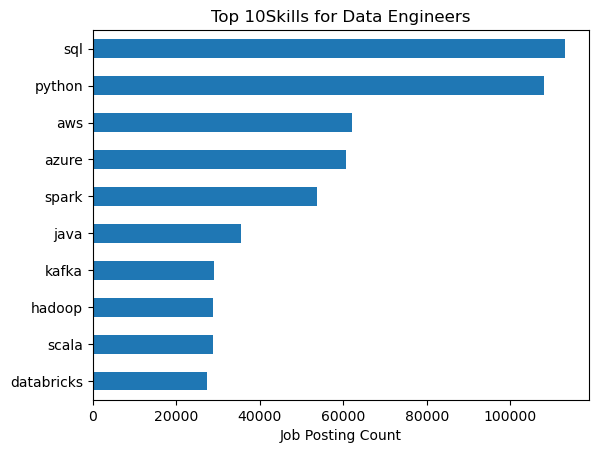

In [6]:
# we want to plot Data Engineer with top ten skills

job_title='Data Engineer'
top_skills=10

df_skill_final = df_skills_count[df_skills_count['job_title_short']==job_title].head(top_skills)

# Lets plot it
df_skill_final.plot(kind='barh',x='job_skills', y='skill_count')
plt.gca().invert_yaxis() # lets invert y axis bars to appear in descending order
plt.title(f'Top {top_skills}Skills for {job_title}s')# Automatically update as per columns we use
plt.xlabel('Job Posting Count')
plt.ylabel('')
plt.legend().set_visible(False) # remove the legend
plt.show()